<a href="https://colab.research.google.com/github/VasavSrivastava/MAT421/blob/main/Hw11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Network Analysis**

## **Graph Models**

- A **graph** is defined as $G = (V, E)$ where:
  - $V$ is the set of **nodes (vertices)**.
  - $E$ is the set of **edges** (connections between nodes).
- Edges can be:
  - **Directed** (one-way): $e(v_i, v_j) \neq e(v_j, v_i)$
  - **Undirected** (two-way): $e(v_i, v_j) = e(v_j, v_i)$
- **Degree** of a node = number of edges connected to it.
  - **In-degree / Out-degree** used in directed graphs (e.g., Twitter).

## **Laplacian Matrix**

- **Adjacency Matrix ($A$):** $A_{ij} = 1$ if there is an edge between $v_i$ and $v_j$.
- **Laplacian Matrix ($L$):** $L = D - A$, where $D$ is the degree matrix.
  - $L_{ii} = \sum_k E_{ik}$ (sum of weights for node $i$)
  - $L_{ij} = -E_{ij}$ if $i \neq j$ and nodes are connected, otherwise 0.
- **Properties:**
  1. $L$ is symmetric and positive semi-definite.
  2. $L \cdot e = 0$, where $e = [1,\dots,1]^T$.
  3. The smallest eigenvalue is 0.
  4. The number of 0 eigenvalues = number of connected components.

## **Spectral Graph Partitioning**

- Goal: partition the graph into clusters such that **inter-cluster connectivity is minimized**.
- **Cut** between partitions $V_1$ and $V_2$:
  $$
  \text{cut}(V_1, V_2) = \sum_{i \in V_1, j \in V_2} A_{ij}
  $$
- **Rayleigh Quotient**:
  $$
  \frac{p^T L p}{p^T p} = \frac{4 \cdot \text{cut}(V_1, V_2)}{n}
  $$
- **Normalized Cut**:
  $$
  \text{Ncut}(V_1, V_2) = \frac{\text{cut}(V_1, V_2)}{\text{vol}(V_1)} + \frac{\text{cut}(V_1, V_2)}{\text{vol}(V_2)}
  $$

## **Spectral Clustering**

- Let $Lx = \lambda x$ be the eigenvalue problem for the Laplacian.
- The **Fiedler vector** (eigenvector for second smallest eigenvalue $\lambda_2$) gives optimal graph cut direction.
- Clustering can be performed using signs or magnitudes of Fiedler vector components.

## **Network Embedding**

- The Fiedler vector $x$ minimizes:
  $$
  x^T L x = \sum_{(i, j) \in E} E_{ij}(x_i - x_j)^2
  $$
- It can be interpreted as mapping nodes to a line (1D embedding), preserving structure.

## **Applications**

- **Community Detection:** Identify groups of nodes more connected within than outside.
- **Recommendation Systems:** Use graph cuts and clustering for suggestions (e.g., friend recommendations).
- **Epidemiological Modeling:** Use graph structure for forecasting disease spread (e.g., influenza prediction).
- **Dimensionality Reduction:** Embed networks into Euclidean space using spectral methods.

## **Key Terms**

- **Adjacency Matrix ($A$)**: Binary/weighted matrix representing edges.
- **Degree Matrix ($D$)**: Diagonal matrix with node degrees.
- **Laplacian ($L = D - A$)**: Matrix central to spectral graph theory.
- **Cut, Ratio Cut, Normalized Cut**: Measures of how well a graph is partitioned.
- **Fiedler Vector**: Second smallest eigenvector of $L$, used for optimal splitting.

> Spectral methods provide scalable and mathematically grounded approaches to understand large-scale networks.


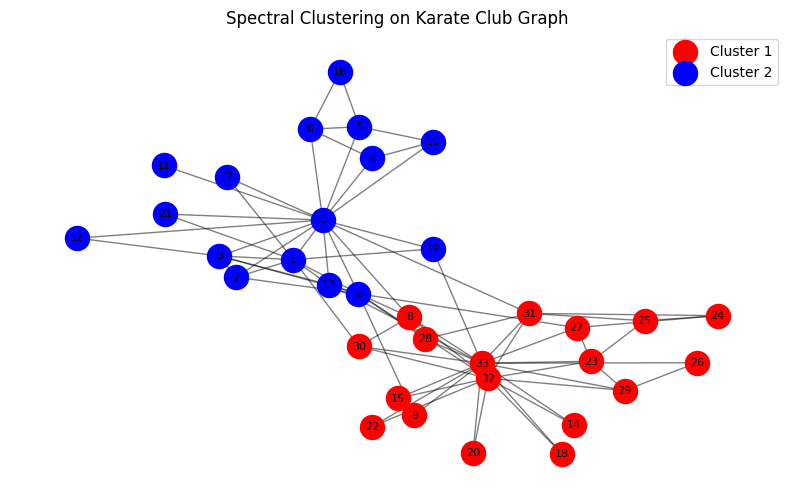

In [3]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.sparse.linalg import eigsh

# Create the Karate Club graph
G = nx.karate_club_graph()

# Get the adjacency matrix as a NumPy array
A = nx.adjacency_matrix(G).toarray()

# Compute degree matrix and Laplacian
degrees = np.sum(A, axis=1)
D = np.diag(degrees)
L = D - A

# Convert Laplacian matrix to float64 (important for eigsh)
L = L.astype(np.float64)

# Compute the smallest 2 eigenvalues and eigenvectors
eigenvalues, eigenvectors = eigsh(L, k=2, which='SM')

# Second smallest eigenvector (Fiedler vector)
fiedler_vector = eigenvectors[:, 1]

# Partition based on sign of Fiedler vector
cluster_1 = np.where(fiedler_vector >= 0)[0]
cluster_2 = np.where(fiedler_vector < 0)[0]

# Plotting
plt.figure(figsize=(10, 6))
pos = nx.spring_layout(G, seed=42)

nx.draw_networkx_nodes(G, pos, nodelist=cluster_1, node_color='red', label='Cluster 1')
nx.draw_networkx_nodes(G, pos, nodelist=cluster_2, node_color='blue', label='Cluster 2')
nx.draw_networkx_edges(G, pos, alpha=0.5)
nx.draw_networkx_labels(G, pos, font_size=8)

plt.title("Spectral Clustering on Karate Club Graph")
plt.legend()
plt.axis('off')
plt.show()